In [1]:
import pymc as pm, polars as pl, arviz as az, numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [3]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/reedfrogs.csv", separator=";").with_columns(
    size=pl.col("size").cast(pl.Categorical),
    predators=pl.col("pred").cast(pl.Categorical),
).with_row_index(name="tank")

In [6]:
with pm.Model(coords={
    "tank": df["tank"].to_numpy(),
    "size": df["size"].unique(),
    "predators": df["predators"].unique()
}) as model:
    # define df
    tank = pm.Data("tank", df["tank"].to_numpy())

    # priors
    beta = pm.Exponential("beta", 1)
    alpha = pm.Normal("alpha", 0, 1)

    alpha_tank = pm.Cauchy("alpha_tank", alpha=alpha, beta=beta, dims="tank")


    survival_prob = pm.Deterministic("survival_prob", pm.math.invlogit(alpha_tank[tank]))

    # observed
    survived = pm.Binomial("survived", n=df["density"].to_numpy(),
                           p=survival_prob, observed=df["surv"].to_numpy())

    # sample posterior
    posterior = pm.sample(chains=4, draws=1000)
    posterior_predictive = pm.sample_posterior_predictive(posterior)
    pm.compute_log_likelihood(posterior)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, alpha, alpha_tank]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [alpha_tank, survived]


Output()

Output()

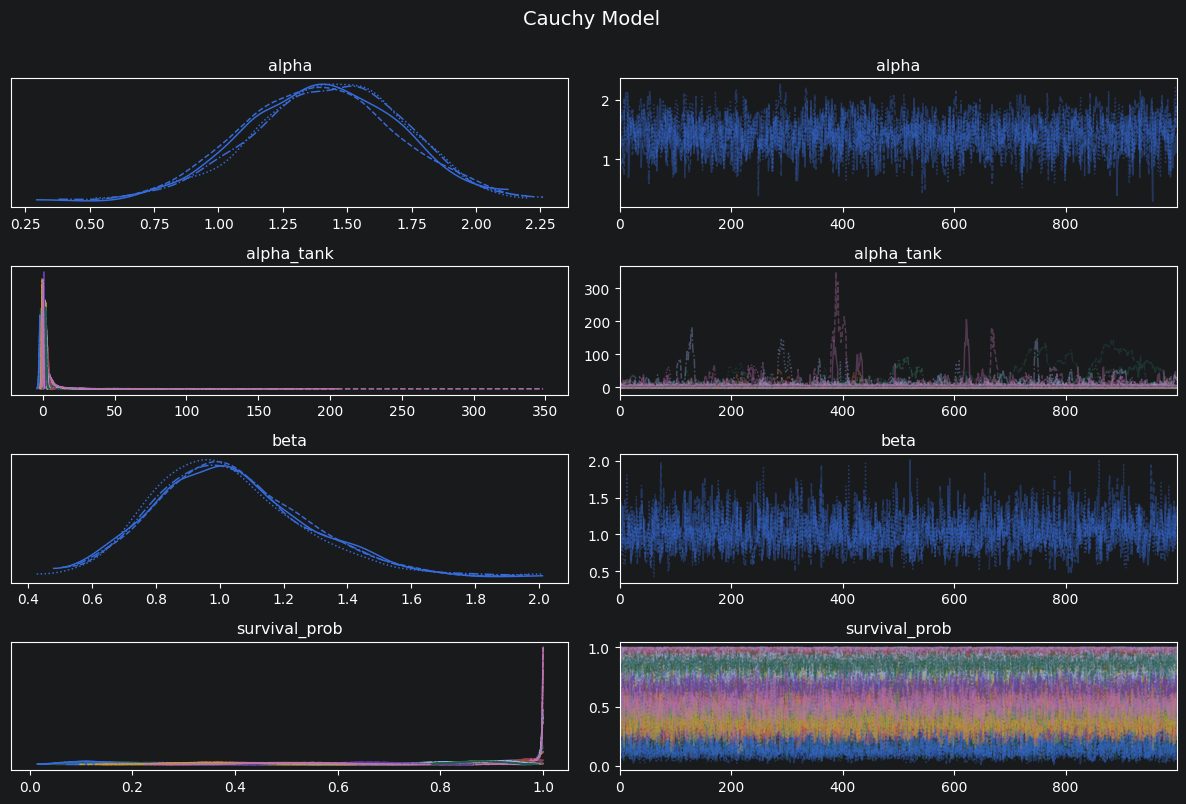

In [11]:
# Plot traces for each model
plot_trace(posterior, title="Cauchy Model", legend=False)